In [16]:
"""
MR-GNODE Analysis Notebook
Cell 1: Setup and Imports
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.linear_model import Ridge
import seaborn as sns
import json
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for publication-quality SVG output
matplotlib.rcParams['svg.fonttype'] = 'none'  # Save fonts as text in SVG
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['axes.linewidth'] = 1.2
matplotlib.rcParams['xtick.major.width'] = 1.2
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['savefig.format'] = 'svg'
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

def load_config(config_path):
    """Load configuration from JSON file"""
    with open(config_path, 'r') as f:
        return json.load(f)

def compute_mse(preds, targets):
    """Compute Mean Squared Error"""
    return float(np.mean((preds - targets) ** 2))

def compute_r2(preds, targets):
    """Compute R-squared"""
    ss_res = np.sum((targets - preds) ** 2)
    ss_tot = np.sum((targets - np.mean(targets)) ** 2)
    return float(1 - (ss_res / ss_tot)) if ss_tot != 0 else 0.0

def count_parameters(model):
    """Count trainable parameters in a model"""
    if hasattr(model, 'parameters'):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return 0

def save_figure(fig, filename, dpi=300):
    """Save figure as high-quality SVG"""
    fig.savefig(f"{filename}.svg", format='svg', dpi=dpi, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    print(f"Saved: {filename}.svg")

print("✓ Imports and setup complete")

Using device: cuda
✓ Imports and setup complete


In [8]:
"""
Cell 2: Load All Pre-trained Models using MRM Infrastructure
"""

import os
import torch

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Import MRM infrastructure (already in src/)
from utils import load_config, create_model, load_cached_model, extract_trajectories
from comparison import generate_common_test_data

print("Loading all pre-trained models from MRM system...")

# =================================
# Load Motor RNN (Ground Truth)
# =================================
print("\n1. Loading Motor RNN (Ground Truth)...")
motor_rnn_config = load_config('configs/motor_rnn.json')
motor_rnn_model = create_model(motor_rnn_config)

# Load pre-trained weights
motor_rnn_model, motor_rnn_metadata, loaded = load_cached_model(
    motor_rnn_config['cache_path'], type(motor_rnn_model), motor_rnn_config
)

if not loaded:
    raise ValueError("Motor RNN not found! Please train it first with: python train.py configs/motor_rnn.json")

print(f"✓ Motor RNN loaded from {motor_rnn_config['cache_path']}")
if motor_rnn_metadata and 'final_r2' in motor_rnn_metadata:
    print(f"  Performance: R² = {motor_rnn_metadata['final_r2']:.3f}")

# =================================
# Load MR-GNODE  
# =================================
print("\n2. Loading MR-GNODE...")
mr_gnode_config = load_config('configs/mr_gnode.json')
mr_gnode_model = create_model(mr_gnode_config)

# =================================
# Load MR-GNODE  
# =================================
print("\n2. Loading MR-GNODE...")
mr_gnode_config = load_config('configs/mr_gnode.json')

# Load like comparison.py does - create model and load state_dict directly
mr_gnode_model = create_model(mr_gnode_config)
mr_gnode_metadata = None

try:
    state_dict = torch.load(f"{mr_gnode_config['cache_path']}/model.pt", map_location=device)
    if any(k.startswith('_orig_mod.') for k in state_dict.keys()):
        state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    mr_gnode_model.load_state_dict(state_dict)
    
    # Try to load metadata
    metadata_path = f"{mr_gnode_config['cache_path']}/metadata.json"
    if os.path.exists(metadata_path):
        import json
        with open(metadata_path, 'r') as f:
            mr_gnode_metadata = json.load(f)
    
    print(f"✓ MR-GNODE loaded from {mr_gnode_config['cache_path']}")
    if mr_gnode_metadata and 'final_r2' in mr_gnode_metadata:
        print(f"  Performance: R² = {mr_gnode_metadata['final_r2']:.3f}")
        
except FileNotFoundError:
    print("  MR-GNODE not found. You can train it with: python train.py configs/mr_gnode.json")
    mr_gnode_model = None
    mr_gnode_metadata = None
except RuntimeError as e:
    if "size mismatch" in str(e):
        print("  ⚠️  MR-GNODE config mismatch - trying with hidden_dim=32...")
        # Try with the parameters that were actually used (from notebook evidence)
        mr_gnode_config_fixed = mr_gnode_config.copy()
        mr_gnode_config_fixed['model_params']['hidden_dim'] = 32
        mr_gnode_model = create_model(mr_gnode_config_fixed)
        mr_gnode_model.load_state_dict(state_dict)
        print(f"✓ MR-GNODE loaded with corrected config from {mr_gnode_config['cache_path']}")
    else:
        raise e

# =================================
# Load MP-rSLDS
# =================================
print("\n3. Loading MP-rSLDS...")
mp_rslds_config = load_config('configs/mp_rslds.json')

# MP-rSLDS uses different loading (pickle-based)
import pickle
import json
mp_rslds_cache = mp_rslds_config['cache_path']
mp_rslds_model_path = os.path.join(mp_rslds_cache, 'model.pkl')
mp_rslds_metadata_path = os.path.join(mp_rslds_cache, 'metadata.json')

mp_rslds_model = None
mp_rslds_metadata = None

if os.path.exists(mp_rslds_model_path) and os.path.exists(mp_rslds_metadata_path):
    with open(mp_rslds_model_path, 'rb') as f:
        mp_rslds_model = pickle.load(f)
    with open(mp_rslds_metadata_path, 'r') as f:
        mp_rslds_metadata = json.load(f)
    
    print(f"✓ MP-rSLDS loaded from {mp_rslds_cache}")
    if mp_rslds_metadata and 'r2' in mp_rslds_metadata:
        print(f"  Performance: R² = {mp_rslds_metadata['r2']:.3f}")
else:
    print("  MP-rSLDS not found. You can train it with: python train.py configs/mp_rslds.json")

# =================================
# Generate Common Test Data
# =================================
print("\n6. Generating common test trajectories...")
test_data = generate_common_test_data()

print(f"✓ Generated {len(test_data['trial_info'])} test trials")
print(f"  Evidence states shape: {test_data['evidence_states'].shape}")
print(f"  Motor states shape: {test_data['motor_states'].shape}")
if 'communications' in test_data and test_data['communications'] is not None:
    print(f"  Communications shape: {test_data['communications'].shape}")
else:
    print("  Communications: Not available")

# =================================
# Load CCA and RRR (if available)  
# =================================
print("\n4. Loading CCA...")
cca_model = None
cca_metadata = None
cca_config = None
if os.path.exists('configs/cca.json'):
    try:
        cca_config = load_config('configs/cca.json')
        # CCA likely uses similar loading pattern as MP-rSLDS
        cca_cache = cca_config['cache_path']
        cca_model_path = os.path.join(cca_cache, 'model.pkl')
        cca_metadata_path = os.path.join(cca_cache, 'metadata.json')
        
        if os.path.exists(cca_model_path) and os.path.exists(cca_metadata_path):
            with open(cca_model_path, 'rb') as f:
                cca_model = pickle.load(f)
            with open(cca_metadata_path, 'r') as f:
                cca_metadata = json.load(f)
            print(f"✓ CCA loaded from {cca_cache}")
            if cca_metadata and 'r2' in cca_metadata:
                print(f"  Performance: R² = {cca_metadata['r2']:.3f}")
        else:
            print("  CCA not found. You can train it with: python train.py configs/cca.json")
    except Exception as e:
        print(f"  CCA config found but loading failed: {e}")
else:
    print("  CCA config not found (configs/cca.json)")

print("\n5. Loading RRR...")
rrr_model = None
rrr_metadata = None
rrr_config = None
if os.path.exists('configs/rrr.json'):
    try:
        rrr_config = load_config('configs/rrr.json')
        # RRR likely uses similar loading pattern as MP-rSLDS
        rrr_cache = rrr_config['cache_path']
        rrr_model_path = os.path.join(rrr_cache, 'model.pkl')
        rrr_metadata_path = os.path.join(rrr_cache, 'metadata.json')
        
        if os.path.exists(rrr_model_path) and os.path.exists(rrr_metadata_path):
            with open(rrr_model_path, 'rb') as f:
                rrr_model = pickle.load(f)
            with open(rrr_metadata_path, 'r') as f:
                rrr_metadata = json.load(f)
            print(f"✓ RRR loaded from {rrr_cache}")
            if rrr_metadata and 'r2' in rrr_metadata:
                print(f"  Performance: R² = {rrr_metadata['r2']:.3f}")
        else:
            print("  RRR not found. You can train it with: python train.py configs/rrr.json")
    except Exception as e:
        print(f"  RRR config found but loading failed: {e}")
else:
    print("  RRR config not found (configs/rrr.json)")

# =================================
# Summary
# =================================
print("\n" + "="*50)
print("MODEL LOADING SUMMARY")
print("="*50)
print(f"✓ Motor RNN: {'Loaded' if motor_rnn_model else 'Missing'}")
print(f"✓ MR-GNODE: {'Loaded' if mr_gnode_model else 'Missing'}")  
print(f"✓ MP-rSLDS: {'Loaded' if mp_rslds_model else 'Missing'}")
print(f"✓ CCA: {'Loaded' if cca_model else 'Missing'}")
print(f"✓ RRR: {'Loaded' if rrr_model else 'Missing'}")
print(f"✓ Test Data: {len(test_data['trial_info'])} trials")
print("="*50)

# Store everything for later use
models = {
    'motor_rnn': motor_rnn_model,
    'mr_gnode': mr_gnode_model, 
    'mp_rslds': mp_rslds_model,
    'cca': cca_model,
    'rrr': rrr_model
}

configs = {
    'motor_rnn': motor_rnn_config,
    'mr_gnode': mr_gnode_config,
    'mp_rslds': mp_rslds_config,
    'cca': cca_config,
    'rrr': rrr_config
}

metadata = {
    'motor_rnn': motor_rnn_metadata,
    'mr_gnode': mr_gnode_metadata,
    'mp_rslds': mp_rslds_metadata,
    'cca': cca_metadata,
    'rrr': rrr_metadata
}

Loading all pre-trained models from MRM system...

1. Loading Motor RNN (Ground Truth)...
✓ Motor RNN loaded from cache/decision_motor_rnn

2. Loading MR-GNODE...

2. Loading MR-GNODE...
✓ MR-GNODE loaded from cache/mr_gnode_fit_dmotor_rnn
  Performance: R² = 0.901

3. Loading MP-rSLDS...
✓ MP-rSLDS loaded from cache/mprslds_fit_dmotor_rnn
  Performance: R² = 0.965

6. Generating common test trajectories...
Generating common test trajectories from RNN...
✓ Generated 20 test trials
  Evidence states shape: (20, 30, 64)
  Motor states shape: (20, 30, 64)
  Communications: Not available

4. Loading CCA...
✓ CCA loaded from cache/cca_baseline
  Performance: R² = 0.731

5. Loading RRR...
✓ RRR loaded from cache/rrr_baseline
  Performance: R² = 0.731

MODEL LOADING SUMMARY
✓ Motor RNN: Loaded
✓ MR-GNODE: Loaded
✓ MP-rSLDS: Loaded
✓ CCA: Loaded
✓ RRR: Loaded
✓ Test Data: 20 trials


In [2]:
import os
os.chdir('src')

PANEL 1: Motor RNN 3D Dynamics
Using utils.extract_trajectories for high-quality dynamics...
Plotting dynamics for 80 trials...
Decision type distribution: LEFT=37, RIGHT=43
Fitting PCA models...
Evidence PCA explained variance: [0.9611068  0.01870606 0.0088171 ]
Motor PCA explained variance: [0.5570028  0.29777086 0.0616757 ]


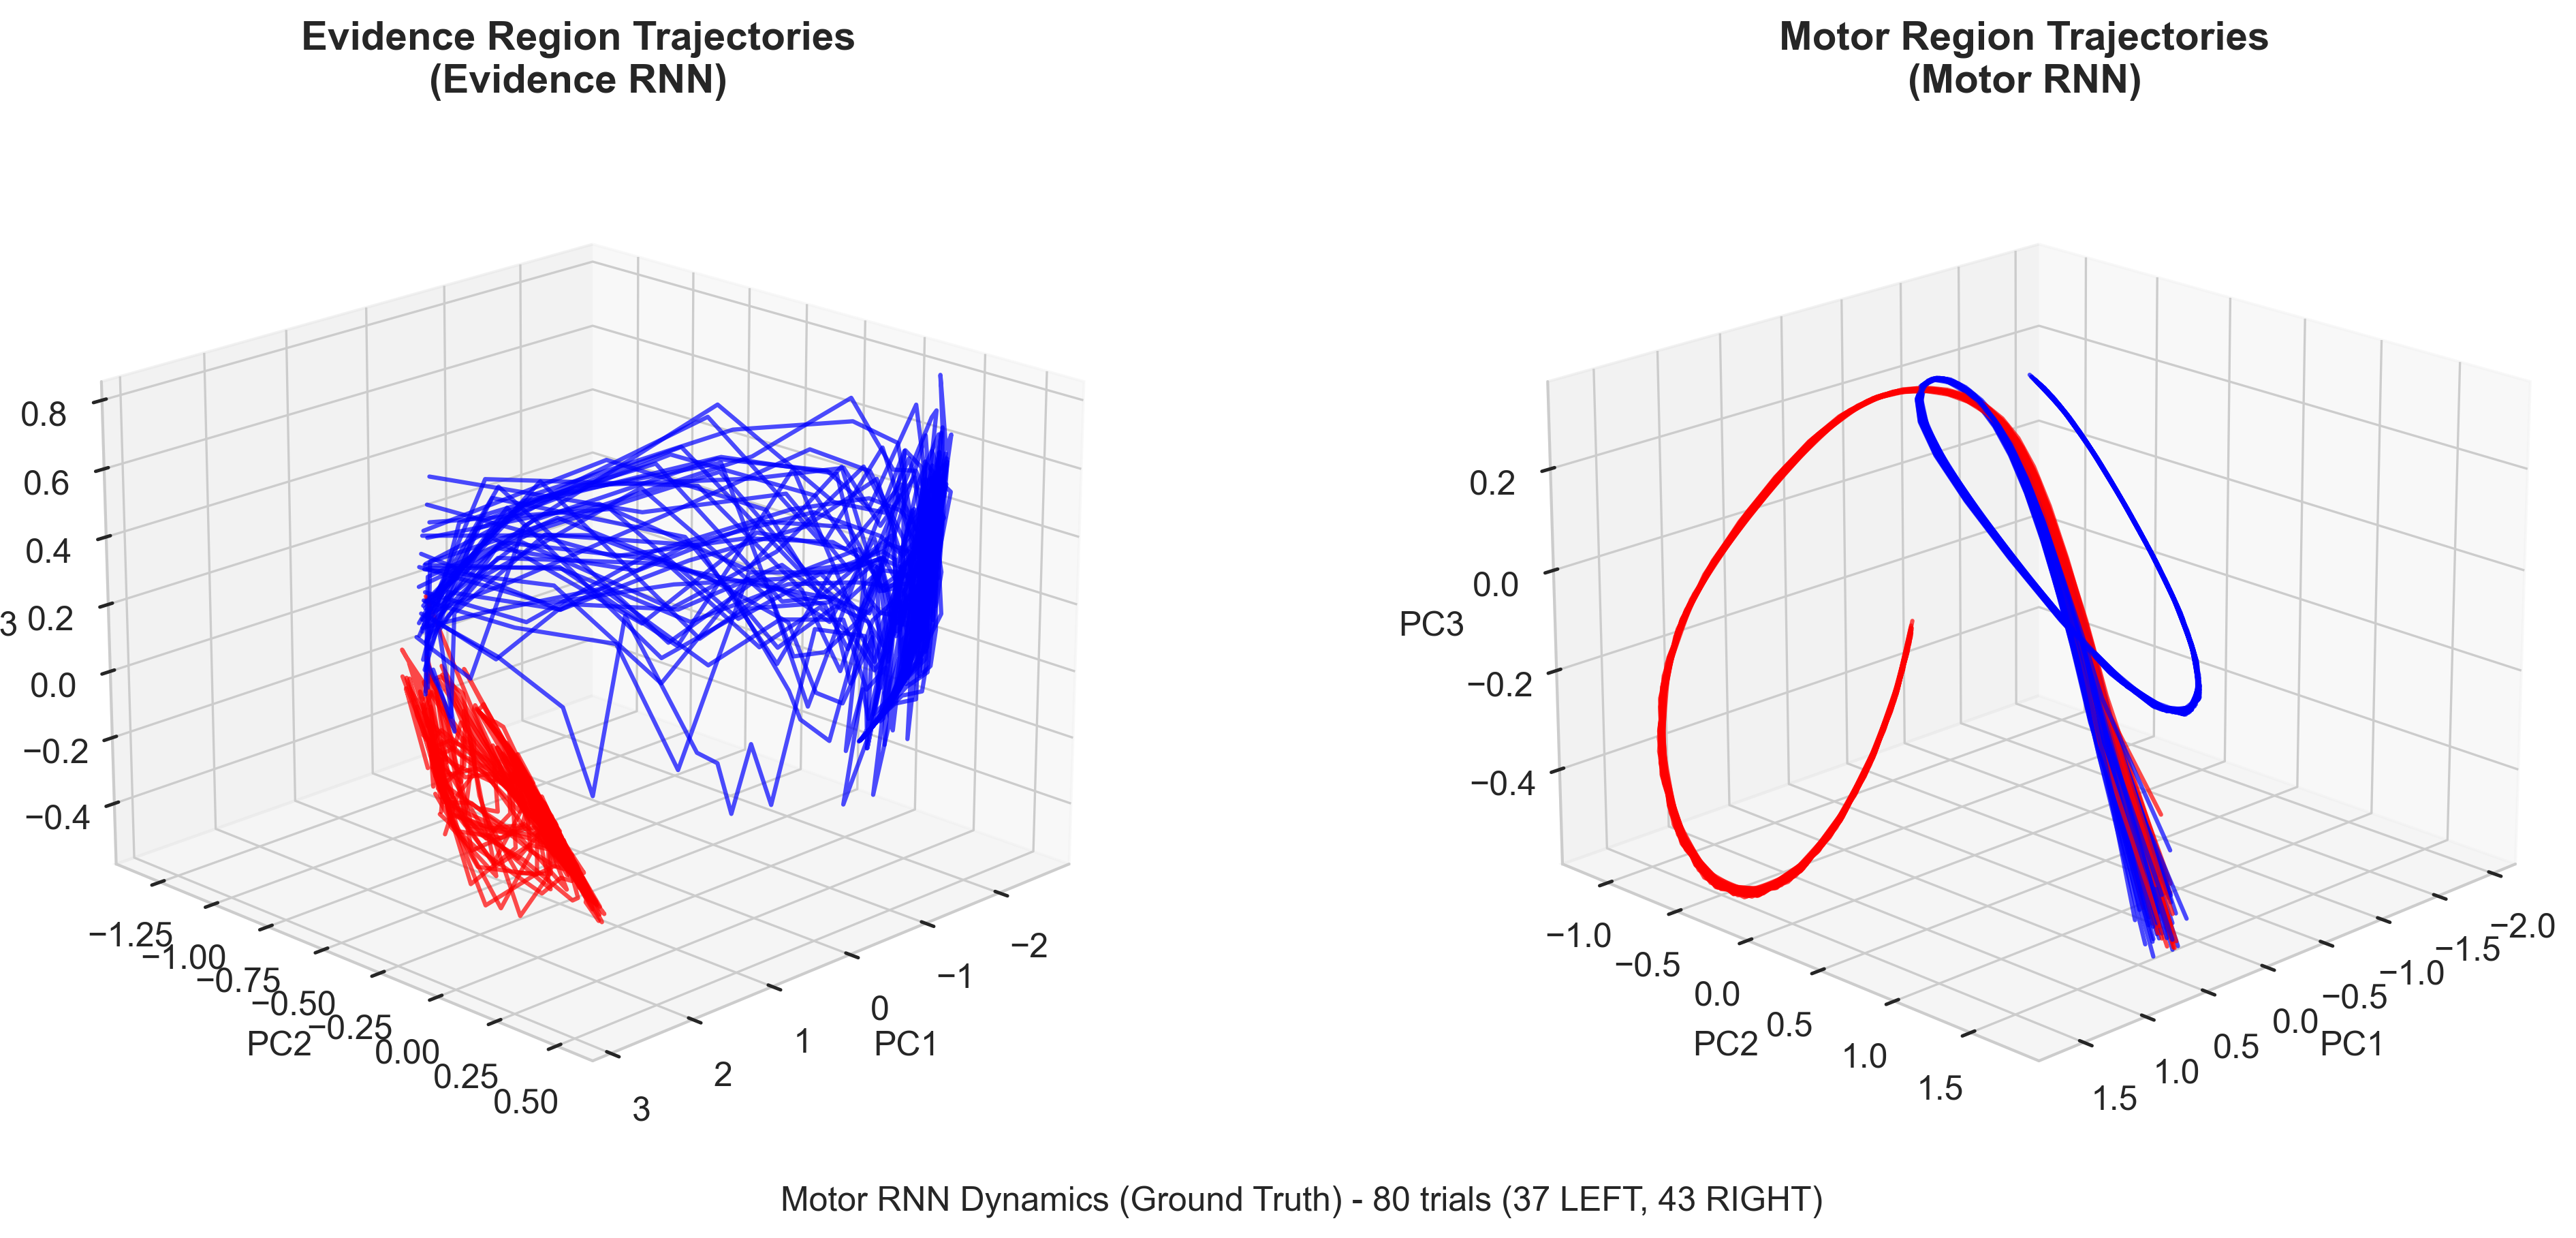

✓ Panel 1 complete
Saved: ev_motor_rnn.svg.svg


In [17]:
"""
Cell 3: Panel 1 - Motor RNN 3D Dynamics Visualization
"""

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_motor_rnn_3d_dynamics(trajectories_data):
    """Create 3D visualization using utils.extract_trajectories data"""
    
    print(f"Plotting dynamics for {len(trajectories_data['trial_info'])} trials...")
    
    # Get all data - utils format
    evidence_states = trajectories_data['evidence_states']
    motor_states = trajectories_data['motor_states']
    decision_types = [info['target'] for info in trajectories_data['trial_info']]
    
    print(f"Decision type distribution: LEFT={decision_types.count(0)}, RIGHT={decision_types.count(1)}")
    
    # Fit PCA models on all data
    print("Fitting PCA models...")
    evidence_flat = evidence_states.reshape(-1, evidence_states.shape[-1])
    motor_flat = motor_states.reshape(-1, motor_states.shape[-1])
    
    evidence_pca = PCA(n_components=3)
    motor_pca = PCA(n_components=3)
    
    evidence_pca_transformed = evidence_pca.fit_transform(evidence_flat)
    motor_pca_transformed = motor_pca.fit_transform(motor_flat)
    
    print(f"Evidence PCA explained variance: {evidence_pca.explained_variance_ratio_[:3]}")
    print(f"Motor PCA explained variance: {motor_pca.explained_variance_ratio_[:3]}")
    
    # Extract trajectories
    time_steps = evidence_states.shape[1]
    evidence_trajs = []
    motor_trajs = []
    
    for trial_idx in range(len(decision_types)):
        start_idx = trial_idx * time_steps
        end_idx = (trial_idx + 1) * time_steps
        
        evidence_trajs.append(evidence_pca_transformed[start_idx:end_idx])
        motor_trajs.append(motor_pca_transformed[start_idx:end_idx])
    
    # Create figure with all trajectories
    fig = plt.figure(figsize=(15, 6))
    colors = {0: 'red', 1: 'blue'}
    
    # Evidence Region 3D - plot ALL trajectories
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    for trial_idx in range(len(decision_types)):
        decision_type = decision_types[trial_idx]
        traj = evidence_trajs[trial_idx]
        color = colors[decision_type]
        
        ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                color=color, alpha=0.7, linewidth=1.5)
    
    ax1.set_title('Evidence Region Trajectories\n(Evidence RNN)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_zlabel('PC3')
    ax1.view_init(elev=20, azim=45)
    
    # Motor Region 3D - plot ALL trajectories
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    for trial_idx in range(len(decision_types)):
        decision_type = decision_types[trial_idx]
        traj = motor_trajs[trial_idx]
        color = colors[decision_type]
        
        ax2.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                color=color, alpha=0.7, linewidth=1.5)
    
    ax2.set_title('Motor Region Trajectories\n(Motor RNN)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_zlabel('PC3')
    ax2.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    
    # Summary
    total_trials = len(decision_types)
    left_count = decision_types.count(0)
    right_count = decision_types.count(1)
    summary_text = f"Motor RNN Dynamics (Ground Truth) - {total_trials} trials ({left_count} LEFT, {right_count} RIGHT)"
    fig.suptitle(summary_text, fontsize=12, y=0.02)
    
    plt.show()
    
    return {
        'evidence_pca': evidence_pca,
        'motor_pca': motor_pca,
        'trajectories': {'evidence': evidence_trajs, 'motor': motor_trajs},
        'decision_types': decision_types
    }, fig

# Execute Panel 1
print("="*50)
print("PANEL 1: Motor RNN 3D Dynamics")
print("="*50)

# Use the utils.extract_trajectories method that gives 88% variance explained
print("Using utils.extract_trajectories for high-quality dynamics...")
from utils import extract_trajectories

# Extract using the proven method
high_quality_trajectories = extract_trajectories(models['motor_rnn'], n_trials=80)

motor_rnn_dynamics, fig = plot_motor_rnn_3d_dynamics(high_quality_trajectories)
print("✓ Panel 1 complete")
save_figure(fig, 'ev_motor_rnn.svg')

In [29]:
"""
Cell 4: Panel 2 - Model Performance Comparison (MSE & R² Bar Charts)
"""

def evaluate_model_predictions(model, model_type, test_data, device):
    """Generate predictions from any model type"""
    
    evidence_states = test_data['evidence_states']
    motor_states = test_data['motor_states']
    
    # Normalize model type name for comparison
    model_type_lower = model_type.lower().replace(' ', '_').replace('-', '_')
    
    if 'mr' in model_type_lower and 'gnode' in model_type_lower:
        # MR-GNODE evaluation using correct interface
        evidence_tensor = torch.tensor(evidence_states, dtype=torch.float32).to(device)
        n_trials, seq_len, _ = evidence_tensor.shape
        dt = 0.01
        all_preds = []
        
        model.eval()
        with torch.no_grad():
            for trial_idx in range(n_trials):
                trial_evidence = evidence_tensor[trial_idx:trial_idx+1]
                
                # Format input for MR-GNODE: [batch, time, regions, channels]
                batch_input = trial_evidence[:, :, :2].unsqueeze(2)
                if hasattr(model, 'num_regions') and model.num_regions == 2:
                    batch_input = batch_input.repeat(1, 1, 2, 1)
                
                # Initialize state
                h = torch.empty(1, model.N_total, device=device)
                torch.nn.init.xavier_uniform_(h)
                outputs = []
                
                for t in range(seq_len):
                    h_dot, _ = model(h, batch_input[:, t], timestep=t)
                    h = h + dt * h_dot
                    step_output = model.get_outputs(h)
                    outputs.append(step_output)
                
                outputs = torch.stack(outputs, dim=1)
                if outputs.shape[2] > 1:
                    preds = outputs.mean(dim=2)
                else:
                    preds = outputs.squeeze(2)
                
                all_preds.append(preds.squeeze(0).cpu().numpy())
        
        predictions = np.array(all_preds)
        targets = motor_states
        
        # Match dimensions
        if predictions.shape[-1] != targets.shape[-1]:
            min_dim = min(predictions.shape[-1], targets.shape[-1])
            predictions = predictions[..., :min_dim]
            targets = targets[..., :min_dim]
            
    elif 'mp' in model_type_lower and 'rslds' in model_type_lower:
        # MP-rSLDS evaluation using the actual model interface
        # Prepare input data (evidence + motor states) 
        evidence_data = test_data['evidence_states']
        motor_data = test_data['motor_states']
        test_states = np.concatenate([evidence_data, motor_data], axis=2)
        
        n_trials, n_time, n_dims = test_states.shape
        test_states_flat = test_states.reshape(-1, n_dims).astype(np.float64)
        
        # Handle both wrapper and direct SLDS objects
        if hasattr(model, 'model'):
            # Wrapper format
            rslds_model = model.model
        else:
            # Direct SLDS object
            rslds_model = model
        
        # Run inference to get reconstructions
        _, posterior = rslds_model.fit(test_states_flat, method="laplace_em", 
                                      initialize=False, num_iters=4)
        reconstructions_flat = rslds_model.smooth(posterior.mean_continuous_states[0], test_states_flat)
        
        # Extract motor reconstructions and targets
        reconstructions = reconstructions_flat.reshape(n_trials, n_time, n_dims)
        motor_dim = evidence_data.shape[2]  # Evidence dimensions
        
        predictions = reconstructions[:, :, motor_dim:]  # Motor reconstructions  
        targets = motor_data  # Ground truth motor states
        
    elif 'cca' in model_type_lower:
        # CCA evaluation
        if hasattr(model, 'predict'):
            # For custom CCA implementations that expect 3D data
            predictions = model.predict(evidence_states)
            targets = motor_states
        else:
            # Standard sklearn CCA approach - expects 2D flattened data
            evidence_flat = evidence_states.reshape(-1, evidence_states.shape[-1])
            motor_flat = motor_states.reshape(-1, motor_states.shape[-1])
            
            # Use transform method for sklearn CCA
            pred_flat = model.transform(evidence_flat, motor_flat)[1]
            predictions = pred_flat.reshape(motor_states.shape)
            targets = motor_states
        
    elif 'rrr' in model_type_lower:
        # RRR evaluation - reduced rank regression
        # evidence_flat = evidence_states.reshape(-1, evidence_states.shape[-1])
        
        if hasattr(model, 'predict'):
            pred_flat = model.predict(evidence_flat)
            predictions = pred_flat.reshape(motor_states.shape)
        else:
            # Custom RRR baseline
            pred_flat = evidence_flat @ model.coef_.T if hasattr(model, 'coef_') else evidence_flat
            predictions = pred_flat.reshape(motor_states.shape)
        
        targets = motor_states
        
    else:
        # Unknown model type - try generic neural network forward pass
        print(f"Warning: Unknown model type '{model_type}', trying generic evaluation...")
        evidence_tensor = torch.tensor(evidence_states, dtype=torch.float32).to(device)
        model.eval()
        with torch.no_grad():
            outputs = model(evidence_tensor)
            if isinstance(outputs, dict):
                # Take the first tensor output
                predictions = list(outputs.values())[0].cpu().numpy()
            else:
                predictions = outputs.cpu().numpy()
        targets = motor_states
    
    return predictions, targets

def plot_model_comparison(results):
    """Create comparison bar charts like comparison.py"""
    
    model_names = list(results.keys())
    mse_values = [results[name]['mse'] for name in model_names]
    r2_values = [results[name]['r2'] for name in model_names]
    param_counts = [results[name]['params'] for name in model_names]
    
    # Filter out failed models (NaN MSE values)
    valid_indices = [i for i, mse in enumerate(mse_values) if not np.isnan(mse)]
    if not valid_indices:
        print("⚠ No valid model results to plot")
        return None
        
    model_names = [model_names[i] for i in valid_indices]
    mse_values = [mse_values[i] for i in valid_indices]
    r2_values = [r2_values[i] for i in valid_indices]
    param_counts = [param_counts[i] for i in valid_indices]
    
    # Create figure with bar charts
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Color scheme
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    # MSE comparison
    bars1 = ax1.bar(model_names, mse_values, color=colors[:len(model_names)], alpha=0.8)
    ax1.set_ylabel('Mean Squared Error', fontweight='bold')
    ax1.set_title('Model Performance: MSE', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars1, mse_values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # R² comparison
    bars2 = ax2.bar(model_names, r2_values, color=colors[:len(model_names)], alpha=0.8)
    ax2.set_ylabel('R-Squared Score', fontweight='bold')
    ax2.set_title('Model Performance: R²', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_ylim(0, 1)
    
    # Add value labels on bars
    for bar, value in zip(bars2, r2_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    
    # Add parameter count info as subtitle
    param_info = ' | '.join([f"{name}: {count:,} params" for name, count in zip(model_names, param_counts) if count > 0])
    if param_info:
        fig.suptitle(f"Parameter Counts: {param_info}", fontsize=10, y=0.02)
    
    return fig

# ================================
# Evaluate All Models
# ================================
print("="*50)
print("PANEL 2: Model Performance Comparison")
print("="*50)

print("Evaluating all models on test data...")

# Use subset of test data for evaluation (first 20 trials)
eval_data = {
    'evidence_states': test_data['evidence_states'][:20],
    'motor_states': test_data['motor_states'][:20],
    'trial_info': test_data['trial_info'][:20]
}

results = {}

# Evaluate each available model
for model_name, model_info in models.items():
    if model_name == "motor_rnn": continue
    # Handle different possible structures of models dictionary
    if isinstance(model_info, dict):
        model_obj = model_info.get('model', None)
        param_count = model_info.get('params', 0)
    else:
        # Direct model object
        model_obj = model_info
        param_count = count_parameters(model_obj) if hasattr(model_obj, 'parameters') else 0
    
    if model_obj is not None:
        print(f"Evaluating {model_name}...")
        
        predictions, targets = evaluate_model_predictions(
            model_obj, model_name, eval_data, device
        )
        
        # Compute metrics
        mse = compute_mse(predictions.flatten(), targets.flatten())
        r2 = compute_r2(predictions.flatten(), targets.flatten())
        
        results[model_name] = {
            'mse': mse,
            'r2': r2,
            'params': param_count
        }
        
        print(f"  ✓ MSE: {mse:.4f}, R²: {r2:.3f}")

# ================================
# Create Comparison Plot
# ================================
if results:
    print(f"\nCreating comparison plot for {len(results)} models...")
    
    # Display results table
    print("\n" + "="*50)
    print("MODEL COMPARISON RESULTS")
    print("="*50)
    for name, metrics in results.items():
        mse_str = f"{metrics['mse']:.4f}" if not np.isnan(metrics['mse']) else "Failed"
        print(f"{name:12} | MSE: {mse_str} | R²: {metrics['r2']:.3f} | Params: {metrics['params']:,}")
    
    # Create plot
    comparison_fig = plot_model_comparison(results)
    
    if comparison_fig is not None:
        print("\n✓ Panel 2 complete")
        save_figure(comparison_fig, 'model_comparison')
    else:
        print("\n⚠ No valid results to plot")
    
else:
    print("⚠ No models available for comparison")

PANEL 2: Model Performance Comparison
Evaluating all models on test data...
Evaluating mr_gnode...
  ✓ MSE: 0.0036, R²: 0.925
Evaluating mp_rslds...


  0%|          | 0/4 [00:00<?, ?it/s]

  ✓ MSE: 0.0008, R²: 0.967
Evaluating cca...
  ✓ MSE: 0.0045, R²: 0.822
Evaluating rrr...
RRR evaluation failed: too many indices for array: array is 2-dimensional, but 3 were indexed
  ✓ MSE: 7.3338, R²: -291.290

Creating comparison plot for 4 models...

MODEL COMPARISON RESULTS
mr_gnode     | MSE: 0.0036 | R²: 0.925 | Params: 10,866
mp_rslds     | MSE: 0.0008 | R²: 0.967 | Params: 0
cca          | MSE: 0.0045 | R²: 0.822 | Params: 0
rrr          | MSE: 7.3338 | R²: -291.290 | Params: 0

✓ Panel 2 complete
Saved: model_comparison.svg
